<a href="https://colab.research.google.com/github/NitoBoritto/El_Farghaly_Bros./blob/main/notebooks/expirement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [649]:
import kagglehub
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.manifold import TSNE
from IPython.display import display
from scipy.stats import skew
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder

In [650]:
path = kagglehub.dataset_download("vivekvivek13/bank-customers-prediction")
df = pd.read_csv(f"{path}/bank.csv", delimiter=';')


Using Colab cache for faster access to the 'bank-customers-prediction' dataset.


In [651]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


## Data_Type Function

In [652]:
    # Shows the data type of each column (int, float, object...)

def inspect_data_types(df):
  print("Data Type Inspection")

  return df.dtypes

inspect_data_types(df)

Data Type Inspection


,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


default : object -> Bool

housing : object -> Bool

loan    : object -> Bool

month   : object -> int OR string

day_of_week : object -> int OR string

## UnKnown Report Function

In [653]:
  # Counts how many 'unknown' values are in each column
def get_unknown_report(df):
    unknown_counts = (df == 'unknown').sum()
    unknown_pct = (unknown_counts / len(df)) * 100

    summary = pd.DataFrame({
        'Unknown Count': unknown_counts,
        'Percentage (%)': unknown_pct.round(2)
    })
    # Filter and sort to show only columns with issues
    return summary[summary['Unknown Count'] > 0].sort_values(by='Unknown Count', ascending=False)

get_unknown_report(df)

,Unknown Count,Percentage (%)
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


## Unique Values Report

---



In [654]:

def show_unique_values(df):
    unique_data = []
    for col in df.columns:
        uniques = df[col].unique()
        unique_data.append({
            'Column Name': col,
            'Unique Count': len(uniques),
            'Sample Values': list(uniques[:15])
        })

    report_df = pd.DataFrame(unique_data)

    print(f"{'='*20} Unique Values Report {'='*20}")
    return report_df

show_unique_values(df)

==================== Unique Values Report ====================


,Column Name,Unique Count,Sample Values
0,age,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5..."
1,job,12,"[housemaid, services, admin., blue-collar, tec..."
2,marital,4,"[married, single, divorced, unknown]"
3,education,8,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
4,default,3,"[no, unknown, yes]"
5,housing,3,"[no, yes, unknown]"
6,loan,3,"[no, yes, unknown]"
7,contact,2,"[telephone, cellular]"
8,month,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, ..."
9,day_of_week,5,"[mon, tue, wed, thu, fri]"


## Job & Marital & Education
---

In [655]:
df['job'].unique()

array(['housemaid', 'services', 'admin.', 'blue-collar', 'technician',
       'retired', 'management', 'unemployed', 'self-employed', 'unknown',
       'entrepreneur', 'student'], dtype=object)

In [656]:
df['education'].unique()

array(['basic.4y', 'high.school', 'basic.6y', 'basic.9y',
       'professional.course', 'unknown', 'university.degree',
       'illiterate'], dtype=object)

In [657]:
df['marital'].unique()

array(['married', 'single', 'divorced', 'unknown'], dtype=object)

In [658]:
# Dictionary containing concise English definitions for each job
def display_job_meanings(df):
    job_definitions = {
        'housemaid': 'Responsible for domestic tasks like cleaning and cooking.',
        'services': 'Jobs in the service sector (e.g., retail, waiters, security).',
        'admin.': 'Office administrators and clerical staff.',
        'blue-collar': 'Manual workers in industries like construction or manufacturing.',
        'technician': 'Specialized technical staff (e.g., IT, engineering support).',
        'retired': 'People who have stopped working permanently due to age.',
        'management': 'Executives and department managers with decision-making roles.',
        'unemployed': 'Individuals who are currently not working.',
        'self-employed': 'Individuals working for themselves (freelancers/contractors).',
        'unknown': 'Missing information regarding the client\'s occupation.',
        'entrepreneur': 'Self-employed individuals running their own business ventures.',
        'student': 'People currently enrolled in schools or universities.'
    }

    # Identifying unique values present in the 'job' column
    unique_jobs = df['job'].unique()

    # Printing a structured header
    print(f"\n{'='*80}")
    print(f"{'JOB CATEGORY':<18} | {'ROLE DESCRIPTION'}")
    print(f"{'='*80}")

    # Iterating and printing each job with its meaning
    for job in sorted(unique_jobs):
        meaning = job_definitions.get(job, "Definition not found.")
        print(f"{job.capitalize():<18} | {meaning}")
        print(f"{'-'*80}")

display_job_meanings(df)


JOB CATEGORY       | ROLE DESCRIPTION
Admin.             | Office administrators and clerical staff.
--------------------------------------------------------------------------------
Blue-collar        | Manual workers in industries like construction or manufacturing.
--------------------------------------------------------------------------------
Entrepreneur       | Self-employed individuals running their own business ventures.
--------------------------------------------------------------------------------
Housemaid          | Responsible for domestic tasks like cleaning and cooking.
--------------------------------------------------------------------------------
Management         | Executives and department managers with decision-making roles.
--------------------------------------------------------------------------------
Retired            | People who have stopped working permanently due to age.
--------------------------------------------------------------------------------
Se

In [659]:
def standardize_text_columns(df):

    # 1. Clean 'job' column: Replace '-' and '.' with spaces
    if 'job' in df.columns:
        df['job'] = df['job'].str.replace('-', ' ', regex=False).str.replace('.', ' ', regex=False).str.strip()

    # 2. Clean 'marital' column: Rename 'divorced' to include widowed reference
    if 'marital' in df.columns:
        df['marital'] = df['marital'].replace('divorced', 'divorced & widowed')

    # 3. Clean 'education' column: Map values to the requested school levels
    education_mapping = {
        'basic.4y': 'primary school',
        'basic.6y': 'middle school',
        'basic.9y': 'secondary school',
        'high.school': 'high school',
        'professional.course': 'professional course',
        'university.degree': 'university degree',
        'illiterate': 'illiterate',
        'unknown': 'unknown'
    }

    if 'education' in df.columns:
        df['education'] = df['education'].replace(education_mapping)

    print("--- Cleaning of Job, Marital, and Education columns is complete. ---")
    return df

standardize_text_columns(df)

--- Cleaning of Job, Marital, and Education columns is complete. ---


,age,job,marital,education,default,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,primary school,no,...,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high school,unknown,...,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high school,no,...,93.994,-36.4,4.857,5191.0,no
3,40,admin,married,middle school,no,...,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high school,no,...,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional course,no,...,94.767,-50.8,1.028,4963.6,yes
41184,46,blue collar,married,professional course,no,...,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university degree,no,...,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional course,no,...,94.767,-50.8,1.028,4963.6,yes


## Month & Day of Weak  Function
---

In [660]:
df['month'].unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'mar', 'apr',
       'sep'], dtype=object)

In [661]:
df['day_of_week'].unique()

array(['mon', 'tue', 'wed', 'thu', 'fri'], dtype=object)

In [662]:
def encode_temporal_columns(df):
    # Convert month names to numbers (Jan=1 → Dec=12)
    month_map = {
        'jan': 1, 'feb': 2, 'mar': 3, 'apr': 4, 'may': 5, 'jun': 6,
        'jul': 7, 'aug': 8, 'sep': 9, 'oct': 10, 'nov': 11, 'dec': 12
    }

    # Convert days to numbers (Mon=1 → Sun=7)
    day_map = {
        'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4,
        'fri': 5, 'sat': 6, 'sun': 7
    }

    # Apply mapping on 'month' column
    if 'month' in df.columns:
        df['month'] = df['month'].str.lower().map(month_map)

    # Apply mapping on 'day_of_week' column
    if 'day_of_week' in df.columns:
        df['day_of_week'] = df['day_of_week'].str.lower().map(day_map)

    print("--- Encoding for 'month' and 'day_of_week' is complete ---")
    return df

# Apply the function
df = encode_temporal_columns(df)
df

--- Encoding for 'month' and 'day_of_week' is complete ---


,age,job,marital,education,default,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,primary school,no,...,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high school,unknown,...,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high school,no,...,93.994,-36.4,4.857,5191.0,no
3,40,admin,married,middle school,no,...,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high school,no,...,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional course,no,...,94.767,-50.8,1.028,4963.6,yes
41184,46,blue collar,married,professional course,no,...,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university degree,no,...,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional course,no,...,94.767,-50.8,1.028,4963.6,yes


## Pdays Column
---

In [663]:
np.sort(df['pdays'].unique())

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  25,  26,  27,
       999])

In [664]:
def transform_pdays(df):
    # create new column
    df['pdays_group'] = df['pdays']

    df.loc[df['pdays'] == 999, 'pdays_group'] = 'not contacted'

    mask = df['pdays'] != 999

    df.loc[mask, 'pdays_group'] = pd.cut(
        df.loc[mask, 'pdays'],
        bins=[-1, 3, 7, 14, 30],
        labels=['last 3 days','last week','last 2 weeks','last month']
    )
    return df

transform_pdays(df)

/tmp/ipykernel_20167/4266335765.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'not contacted' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df['pdays'] == 999, 'pdays_group'] = 'not contacted'


,age,job,marital,education,default,...,cons.conf.idx,euribor3m,nr.employed,y,pdays_group
0,56,housemaid,married,primary school,no,...,-36.4,4.857,5191.0,no,not contacted
1,57,services,married,high school,unknown,...,-36.4,4.857,5191.0,no,not contacted
2,37,services,married,high school,no,...,-36.4,4.857,5191.0,no,not contacted
3,40,admin,married,middle school,no,...,-36.4,4.857,5191.0,no,not contacted
4,56,services,married,high school,no,...,-36.4,4.857,5191.0,no,not contacted
...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional course,no,...,-50.8,1.028,4963.6,yes,not contacted
41184,46,blue collar,married,professional course,no,...,-50.8,1.028,4963.6,no,not contacted
41185,56,retired,married,university degree,no,...,-50.8,1.028,4963.6,no,not contacted
41186,44,technician,married,professional course,no,...,-50.8,1.028,4963.6,yes,not contacted


In [665]:
df['pdays_group'].unique()

array(['not contacted', 'last week', 'last 3 days', 'last 2 weeks',
       'last month'], dtype=object)

In [666]:
def get_pdays_summary(df):

    # Create a temporary series to hold labels
    temp_series = df['pdays'].astype(object)

    # 1. Identify and label the contacted group
    mask = df['pdays'] != 999
    temp_series.loc[mask] = pd.cut(
        df.loc[mask, 'pdays'],
        bins=[-1, 3, 7, 14, 30],
        labels=['last 3 days', 'last week', 'last 2 weeks', 'last month']
    )

    # 2. Label the 'not contacted' group
    temp_series.loc[df['pdays'] == 999] = 'not contacted'

    # 3. Create the summary table
    summary = temp_series.value_counts().reset_index()
    summary.columns = ['Bin Label', 'Count']
    summary['Percentage (%)'] = (summary['Count'] / len(df) * 100).round(2)

    return summary

get_pdays_summary(df)

,Bin Label,Count,Percentage (%)
0,not contacted,39673,96.32
1,last week,636,1.54
2,last 3 days,541,1.31
3,last 2 weeks,276,0.67
4,last month,62,0.15






## Outlires Dettection
---

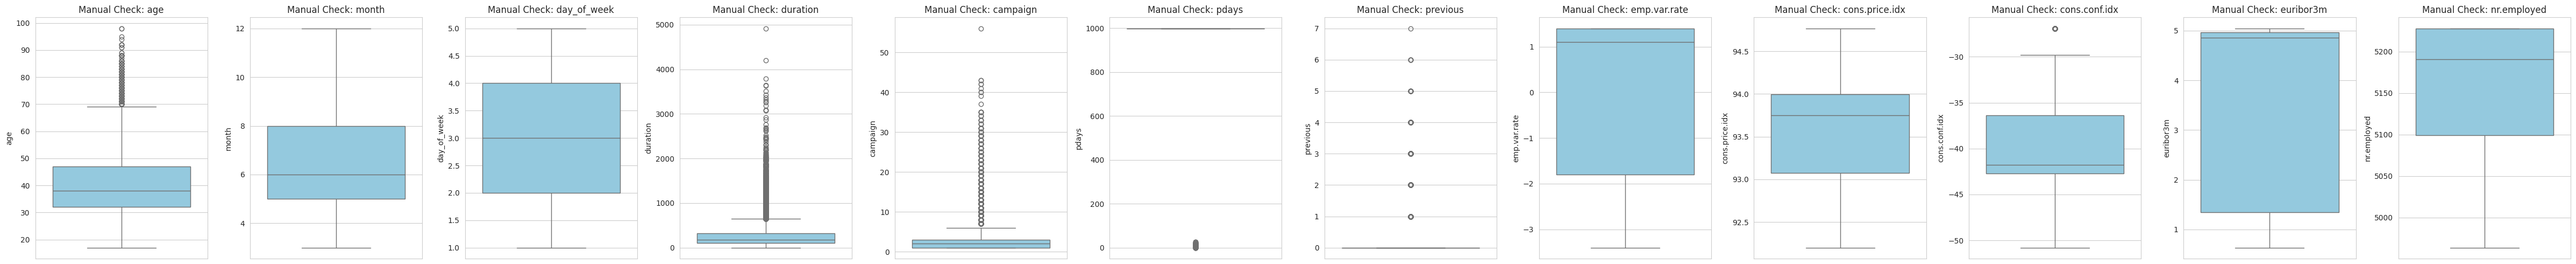

,Column,Outlier Count,Percentage (%)
0,age,469,1.14
1,month,0,0.00
2,day_of_week,0,0.00
3,duration,2963,7.19
4,campaign,2406,5.84
5,pdays,1515,3.68
6,previous,5625,13.66
7,emp.var.rate,0,0.00
8,cons.price.idx,0,0.00
9,cons.conf.idx,447,1.09


In [667]:

def detect_outliers(df, show_plots=True):

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    summary_data = []

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        count = len(outliers)

        summary_data.append({
            'Column': col,
            'Outlier Count': count,
            'Percentage (%)': round((count / len(df)) * 100, 2)
        })

    if show_plots:
        num_cols = len(numeric_cols)
        fig, axes = plt.subplots(1, num_cols, figsize=(num_cols * 4, 5))
        if num_cols == 1: axes = [axes]
        for i, col in enumerate(numeric_cols):
            sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
            axes[i].set_title(f'Manual Check: {col}')
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(summary_data)

detect_outliers(df)

##  IsolationForest


In [668]:
def handle_outliers_isolation_forest(df, contamination=0.05):

    df_cleaned = df.copy()

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    if numeric_cols.empty:
        print("No numerical columns found.")
        return df_cleaned


    iso = IsolationForest(contamination=contamination, random_state=42)


    data_for_model = df[numeric_cols].fillna(df[numeric_cols].median())
    preds = iso.fit_predict(data_for_model)

    outlier_indices = df.index[preds == -1]
    df_cleaned = df_cleaned.drop(index=outlier_indices)

    print(f"\n--- Isolation Forest Summary ---")
    print(f"Total Rows Before: {len(df)}")
    print(f"Detected and Removed: {len(outlier_indices)} rows ({(len(outlier_indices)/len(df)*100):.2f}%)")
    print(f"Total Rows After: {len(df_cleaned)}")
    print("-" * 32)

    return df_cleaned
df=handle_outliers_isolation_forest(df)


--- Isolation Forest Summary ---
Total Rows Before: 41188
Detected and Removed: 2060 rows (5.00%)
Total Rows After: 39128
--------------------------------


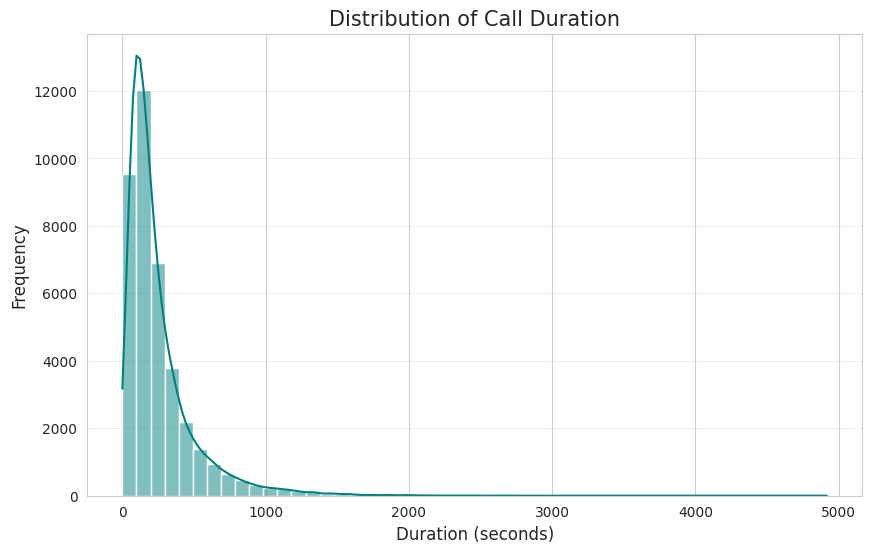

In [669]:
plt.figure(figsize=(10, 6))
sns.histplot(df['duration'], kde=True, color='teal', bins=50)
plt.title('Distribution of Call Duration', fontsize=15)
plt.xlabel('Duration (seconds)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

### After Islation Forest

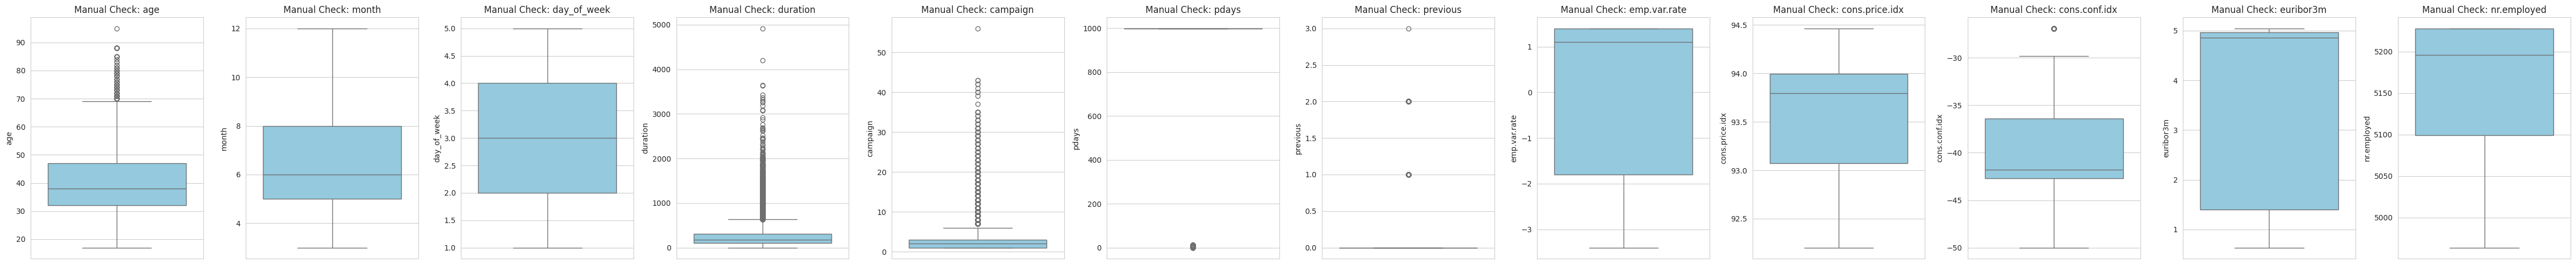

,Column,Outlier Count,Percentage (%)
0,age,154,0.39
1,month,0,0.00
2,day_of_week,0,0.00
3,duration,2811,7.18
4,campaign,2357,6.02
5,pdays,273,0.70
6,previous,3957,10.11
7,emp.var.rate,0,0.00
8,cons.price.idx,0,0.00
9,cons.conf.idx,233,0.60


In [670]:
detect_outliers(df)

## Imputation
---

/tmp/ipykernel_20167/782091874.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unknown_pct.values, y=unknown_pct.index, palette='Reds_r')


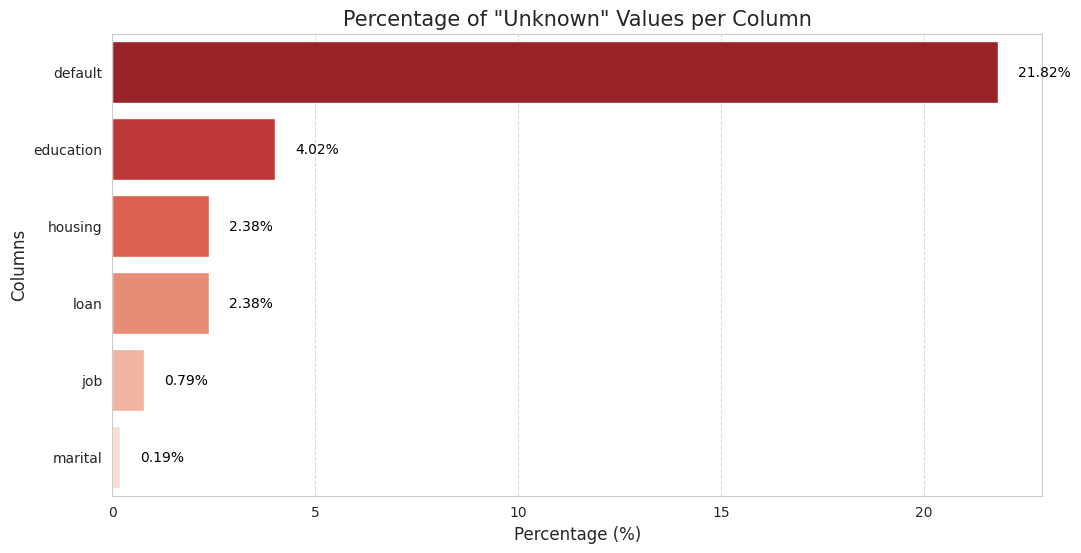

,Count,Percentage (%)
default,8537,21.82
education,1572,4.02
housing,933,2.38
loan,933,2.38
job,308,0.79
marital,74,0.19


In [671]:
def plot_unknown_values(df):

    unknown_counts = (df == 'unknown').sum()
    unknown_data = unknown_counts[unknown_counts > 0].sort_values(ascending=False)
    if unknown_data.empty:
        print("No 'unknown' values found in the dataset.")
        return
    unknown_pct = (unknown_data / len(df)) * 100
    plt.figure(figsize=(12, 6))
    sns.barplot(x=unknown_pct.values, y=unknown_pct.index, palette='Reds_r')
    for i, v in enumerate(unknown_pct.values):
        plt.text(v + 0.5, i, f'{v:.2f}%', color='black', va='center')
    plt.title('Percentage of "Unknown" Values per Column', fontsize=15)
    plt.xlabel('Percentage (%)', fontsize=12)
    plt.ylabel('Columns', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    summary = pd.DataFrame({'Count': unknown_data, 'Percentage (%)': unknown_pct.round(2)})
    return summary

plot_unknown_values(df)

In [672]:
# 1. Convert 'unknown' strings to actual NaN values so the library can detect them
df.replace('unknown', np.nan, inplace=True)

# ==========================================
# Chart 1: Bar Chart
# Shows the total count of non-missing values per column
# ==========================================
msno.bar(df, figsize=(12, 6), color="dodgerblue", fontsize=12)
plt.title('Count of Complete Data per Column', fontsize=16)
plt.show()

# ==========================================
# Chart 2: Matrix Plot
# Excellent for seeing WHERE the missing values are and if they are related
# ==========================================
msno.matrix(df, figsize=(12, 6), color=(0.2, 0.4, 0.6), sparkline=False)
plt.title('Missing Data Map (White lines indicate missing values)', fontsize=16)
plt.show()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,pdays_group
0,56,housemaid,married,primary school,no,no,no,telephone,5,1,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,not contacted
1,57,services,married,high school,unknown,no,no,telephone,5,1,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,not contacted
2,37,services,married,high school,no,yes,no,telephone,5,1,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,not contacted
3,40,admin,married,middle school,no,no,no,telephone,5,1,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,not contacted
4,56,services,married,high school,no,no,yes,telephone,5,1,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,not contacted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40847,40,admin,divorced & widowed,high school,no,yes,yes,telephone,9,3,...,999,1,failure,-1.1,94.199,-37.5,0.886,4963.6,no,not contacted
40848,35,admin,married,university degree,no,no,yes,cellular,9,3,...,999,1,failure,-1.1,94.199,-37.5,0.886,4963.6,no,not contacted
40850,30,student,single,high school,no,yes,no,cellular,9,3,...,999,0,nonexistent,-1.1,94.199,-37.5,0.886,4963.6,no,not contacted
40852,34,admin,married,university degree,no,no,yes,cellular,9,3,...,999,0,nonexistent,-1.1,94.199,-37.5,0.886,4963.6,yes,not contacted


In [674]:

cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

reverse_mappings = {}

for col in cat_cols:
    unique_vals = df[col].dropna().unique()
    mapping = {val: i for i, val in enumerate(unique_vals)}
    reverse_mappings[col] = {i: val for i, val in enumerate(unique_vals)}
    df[col] = df[col].map(mapping)

imputer = IterativeImputer(random_state=42, max_iter=10)
df.iloc[:, :] = imputer.fit_transform(df)

for col in cat_cols:
    df[col] = np.round(df[col])

    max_idx = len(reverse_mappings[col]) - 1
    df[col] = np.clip(df[col], 0, max_idx)

    df[col] = df[col].map(reverse_mappings[col])

AttributeError: 'numpy.ndarray' object has no attribute 'replace'

In [ ]:
plot_unknown_values(df)

# EDA

## Information Dataset

In [ ]:
df.info()

In [ ]:
df.shape

In [ ]:
df.describe()

## Charts 

### Visualizing the Target Variable Distribution (Class Balance)
The very first step in any classification project is to check the distribution of your target variable (`y`). We use a simple **Countplot** (bar chart) to see how many instances of 'yes' and 'no' exist.

In [ ]:
sns.countplot(x = 'y',data = df)
plt.title('Target Variable Distribution (y)')
plt.show()

### Visualizing Numerical Features and Outliers vs Target Variable
To understand how numerical features vary across the target classes (and to identify potential outliers), we use a grid of **Boxplots**. This allows us to see the median, spread, and extreme values of each feature for both the 'yes' and 'no' outcomes simultaneously.

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(16, 18))
for i, col in enumerate(num_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(x='y', y=col, data=df, palette='Set2')
    plt.title(f'Outliers in {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Target (y)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Visualizing Categorical Features vs Target Variable
To understand the relationship between categorical attributes and the target variable `y`, we use a grid of **Grouped Bar Charts**. This helps identify which categories have a higher conversion rate (e.g., which jobs or education levels are more likely to say "yes").

In [ ]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']

fig, axes = plt.subplots(3, 2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='y', data=df, ax=axes[i], palette='Set1')
    axes[i].set_title(f'{col.capitalize()} vs Target (y)', fontsize=14, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45) 
    axes[i].set_ylabel('Count')


plt.tight_layout()
plt.show()

### Visualizing Data Distributions (KDE Plots)
To understand the underlying distribution of our numerical features and see how well they separate our target classes, we use **Kernel Density Estimate (KDE) plots**. A KDE plot is like a smoothed histogram. If the curves for 'yes' and 'no' are heavily overlapping, the feature might not be very useful. If the peaks are separated, the feature is a strong predictor.

In [ ]:
for col in num_cols:
    plt.figure(figsize=(8, 5))
    
    
    sns.kdeplot(data=df, x=col, hue='y', fill=True, palette='Set2')
    
    plt.title(f'Distribution of {col} by Target') 
    plt.show()
    print("-" * 50)

### Visualizing Categorical Features Individually
Instead of plotting all categorical features in a single large grid, we can loop through them one by one. This approach gives each chart more space, making it easier to read the X-axis labels (like long job titles or education levels) and allowing us to focus on one feature at a time.

In [ ]:
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))

axes = axes.flatten() 

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, hue='y', data=df, ax=axes[i])
    
    axes[i].set_title(col, fontsize=14, fontweight='bold')
    
    axes[i].tick_params(axis='x', rotation=45)
    
    axes[i].set_ylabel('count')

plt.tight_layout()
plt.show()

### Visualizing Feature Correlation with the Target
To determine which numerical features have the strongest mathematical relationship with our target variable, we calculate the **Pearson Correlation Coefficient**.

In [ ]:
df = df.dropna()
mapping = {'no': 0, 'yes': 1}
df['y'] = df['y'].map(mapping)

corr = df.corr(numeric_only = True).drop('y')

matrix = corr[['y']].sort_values(by = 'y', ascending = False)

plt.figure(figsize = (4, 8))
sns.heatmap(matrix,
            annot = True,
            fmt = '.2f',
            cmap = 'coolwarm',
            vmin = -1,
            vmax = 1)
plt.title('Correlation of features with target')
plt.tight_layout()
plt.show()

### Dimensionality Reduction and Visualization (t-SNE)
To understand if our features contain natural patterns or clusters that separate the target classes, we use **t-SNE** (t-Distributed Stochastic Neighbor Embedding).

In [ ]:
# بنشيل الـ target ونعمل t-SNE على الـ features بس
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=300)

X = df.drop(columns='y')
y = df['y']

X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='Set2', alpha=0.5, s=10)
plt.colorbar(scatter)
plt.title('t-SNE Visualization')
plt.show()